In [ ]:
!pip install torch transformers flask pandas numpy matplotlib seaborn scikit-learn


In [ ]:
pip install --upgrade transformers


In [ ]:
import pandas as pd

# Load dataset
data = pd.read_csv("/content/drive/MyDrive/colabdata/train.csv.zip")

# Print available columns
print("Columns in dataset:", data.columns)



Columns in dataset: Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')


Column 'toxicity_scores' not found. Skipping drop.


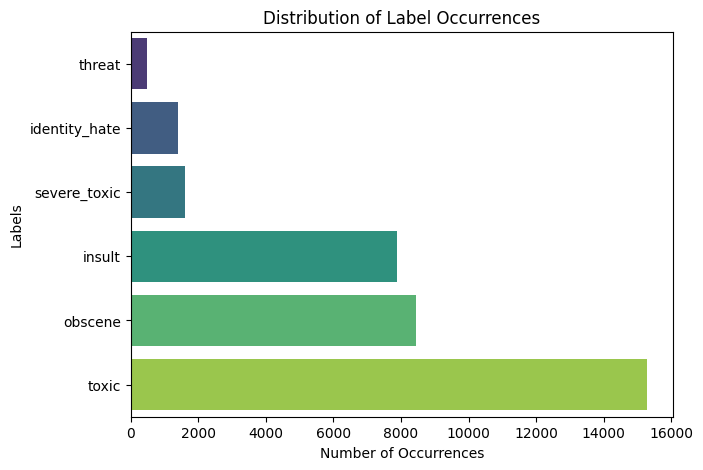

Available columns in dataframe: Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Training Samples: (18918,)
Input Ids Shape: torch.Size([18918, 128])
Attention Masks Shape: torch.Size([18918, 128])
Labels Shape: torch.Size([18918, 6])


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score


# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Load dataset
data = pd.read_csv("/content/drive/MyDrive/colabdata/train.csv.zip")

# Drop only if the column exists
if "toxicity_scores" in data.columns:
    data = data.drop("toxicity_scores", axis=1)
else:
    print("Column 'toxicity_scores' not found. Skipping drop.")


# Extract column labels
column_labels = data.columns.tolist()[2:]

# Plot label distribution
label_counts = data[column_labels].sum().sort_values()
plt.figure(figsize=(7, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')
plt.xlabel('Number of Occurrences')
plt.ylabel('Labels')
plt.title('Distribution of Label Occurrences')
plt.show()

# Balance dataset (9000 clean + toxic comments)
train_toxic = data[data[column_labels].sum(axis=1) > 0]
train_clean = data[data[column_labels].sum(axis=1) == 0]
train_clean_sampled = train_clean.sample(n=9000, random_state=42)
dataframe = pd.concat([train_toxic, train_clean_sampled], axis=0).sample(frac=1, random_state=42)

# Check columns before splitting
print("Available columns in dataframe:", dataframe.columns)

# Train-Test Split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    dataframe['comment_text'], dataframe.iloc[:, 2:], test_size=0.25, random_state=42
)

# Test-Validation Split
test_texts, val_texts, test_labels, val_labels = train_test_split(
    test_texts, test_labels, test_size=0.5, random_state=42
)


def tokenize_and_encode(tokenizer, comments, labels, max_length=128):
    input_ids = []
    attention_masks = []

    for comment in comments:
        encoded_dict = tokenizer.encode_plus(
            comment,
            add_special_tokens=True,   # Add [CLS] and [SEP]
            max_length=max_length,     # Set max length
            padding='max_length',      # Pad shorter sequences
            truncation=True,           # Truncate longer sequences
            return_attention_mask=True,
            return_tensors='pt'        # Return PyTorch tensors
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])

    return torch.cat(input_ids, dim=0), torch.cat(attention_masks, dim=0), torch.tensor(labels.values, dtype=torch.float32)

# Load Pretrained Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

# Tokenize Data
input_ids, attention_masks, labels = tokenize_and_encode(tokenizer, train_texts, train_labels)
test_input_ids, test_attention_masks, test_labels = tokenize_and_encode(tokenizer, test_texts, test_labels)
val_input_ids, val_attention_masks, val_labels = tokenize_and_encode(tokenizer, val_texts, val_labels)

print(f'Training Samples: {train_texts.shape}')
print(f'Input Ids Shape: {input_ids.shape}')
print(f'Attention Masks Shape: {attention_masks.shape}')
print(f'Labels Shape: {labels.shape}')


In [ ]:
import torch
torch.cuda.empty_cache()


In [ ]:
def add_toxic_column(labels):
    if labels.shape[1] == 5:  # If the 'toxic' column is missing
        toxic_column = torch.zeros(labels.shape[0], 1)  # Add a new column with zeros
        labels = torch.cat((toxic_column, labels), dim=1)
    return labels


In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Add 'toxic' column if missing
labels_with_toxic = add_toxic_column(labels)

# Recreate the DataLoader
train_loader = DataLoader(TensorDataset(input_ids, attention_masks, labels_with_toxic), batch_size=32, shuffle=True)


In [ ]:
for batch in train_loader:
    input_ids, attention_mask, labels = batch
    print("Input IDs:", input_ids.shape)
    print("Attention Mask:", attention_mask.shape)
    print("Labels:", labels.shape)
    break


Input IDs: torch.Size([32, 128])
Attention Mask: torch.Size([32, 128])
Labels: torch.Size([32, 6])


In [ ]:
for batch in train_loader:
    print("Batch Loaded ✅")
    print(batch)
    break


Batch Loaded ✅
[tensor([[  101,  1000,  3433,  ...,  2009,  1010,   102],
        [  101,  1000,  1045,  ...,  2123,  1005,   102],
        [  101,  2017,  7743,  ...,     0,     0,     0],
        ...,
        [  101,  1045,  2215,  ...,     0,     0,     0],
        [  101,  2821, 12731,  ...,     0,     0,     0],
        [  101,  1000,  1000,  ...,     0,     0,     0]]), tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), tensor([[0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [1., 0., 1., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 1., 0.],
        [1., 0., 1., 1., 1., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [1., 0., 1., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.,

In [ ]:
print("Input IDs:", input_ids.shape)
print("Attention Mask:", attention_masks.shape)
print("Labels:", labels.shape)


Input IDs: torch.Size([32, 128])
Attention Mask: torch.Size([18918, 128])
Labels: torch.Size([32, 6])


In [ ]:
# Load Pretrained BERT Model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=6)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Function to add 'toxic' column if missing
def add_toxic_column(labels):
    if labels.shape[1] == 5:  # If 'toxic' is missing
        toxic_column = torch.zeros(labels.shape[0], 1)
        labels = torch.cat((toxic_column, labels), dim=1)
    return labels

# Re-tokenize the data
def tokenize_and_encode(tokenizer, texts, labels, max_length=128):
    input_ids = []
    attention_masks = []
    for text in texts:
        encoded_dict = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_length,
            pad_to_max_length=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])
    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    labels = torch.tensor(labels, dtype=torch.float32)
    return input_ids, attention_masks, labels

# Encode the data
input_ids, attention_masks, labels = tokenize_and_encode(tokenizer, train_texts, train_labels.values)
labels_with_toxic = add_toxic_column(labels)

# Create Dataloaders
train_loader = DataLoader(TensorDataset(input_ids, attention_masks, labels_with_toxic), batch_size=32, shuffle=True)

# Define Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Training Function
def train_model(model, train_loader, optimizer, device, num_epochs=3):
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            input_ids, attention_mask, labels = [t.to(device) for t in batch]
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

        print(f'Epoch {epoch+1}, Training Loss: {total_loss/len(train_loader)}')

# Train Model
train_model(model, train_loader, optimizer, device, num_epochs=3)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


Epoch 1, Training Loss: 0.23962650974155278
Epoch 2, Training Loss: 0.1692786506704382
Epoch 3, Training Loss: 0.14284669367495823


In [ ]:
# Model Evaluation
def evaluate_model(model, test_loader, device):
    model.eval()
    true_labels, predicted_probs = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = [t.to(device) for t in batch]
            outputs = model(input_ids, attention_mask=attention_mask)
            predicted_probs.append(torch.sigmoid(outputs.logits).cpu().numpy())
            true_labels.append(labels.cpu().numpy())

    # Convert to numpy arrays
    true_labels = np.concatenate(true_labels, axis=0)
    predicted_probs = np.concatenate(predicted_probs, axis=0)
    predicted_labels = (predicted_probs > 0.5).astype(int)

    # Compute Metrics
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='micro')
    recall = recall_score(true_labels, predicted_labels, average='micro')
    f1_score = 2 * (precision * recall) / (precision + recall)

    print(f'Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1_score:.4f}')

# Add 'toxic' column to test labels
test_labels_with_toxic = add_toxic_column(test_labels)

# Create Test DataLoader
test_loader = DataLoader(TensorDataset(test_input_ids, test_attention_masks, test_labels_with_toxic), batch_size=32, shuffle=False)

# Evaluate Model
evaluate_model(model, test_loader, device)



Accuracy: 0.6280, Precision: 0.7833, Recall: 0.8924, F1 Score: 0.8343


In [ ]:
output_dir = "Saved_BERT_Model"
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

('Saved_BERT_Model/tokenizer_config.json',
 'Saved_BERT_Model/special_tokens_map.json',
 'Saved_BERT_Model/vocab.txt',
 'Saved_BERT_Model/added_tokens.json')

In [ ]:
!zip -r bert_model.zip Saved_BERT_Model


  adding: Saved_BERT_Model/ (stored 0%)
  adding: Saved_BERT_Model/special_tokens_map.json (deflated 42%)
  adding: Saved_BERT_Model/tokenizer_config.json (deflated 75%)
  adding: Saved_BERT_Model/vocab.txt (deflated 53%)
  adding: Saved_BERT_Model/model.safetensors (deflated 7%)
  adding: Saved_BERT_Model/config.json (deflated 54%)


In [ ]:
from google.colab import files
files.download("bert_model.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>